# 이미지 생성 및 평가와 모델 학습 - 실습

---

## 학습 개요

1. **학습 주제**
  - **텍스트-투-이미지 생성**: 디퓨전 기반 생성 모델(SANA)을 활용한 프롬프트 기반 이미지 생성
  - **멀티모달 이미지 평가**: CLIP 모델을 활용한 이미지-텍스트 유사도 측정 및 CNN 모델과의 비교 분석
  - **전이학습과 합성 데이터 활용**: 생성 이미지를 활용한 ResNet-18 전이학습(리니어 프로빙) 파이프라인 구축

2. **학습 목표**
  - 디퓨전 모델의 이미지 생성 원리를 이해하고, **SANA 파이프라인으로 텍스트 기반 이미지를 생성**할 수 있다.
  - CLIP 모델을 활용하여 **이미지와 텍스트 간 의미적 유사도를 측정**하고 결과를 해석할 수 있다.
  - 동일 이미지에 대해 **CLIP과 ResNet-50의 분류 결과를 비교**하고 각 모델의 특성 차이를 설명할 수 있다.
  - 합성 데이터셋을 구성하고 사전학습된 ResNet-18에 대해 **전이학습(리니어 프로빙)을 구현**할 수 있다.

3. **핵심 개념**
  - **디퓨전 모델(Diffusion Model)**: 노이즈가 가득한 이미지에서 시작하여 점진적으로 노이즈를 제거하며 텍스트 조건에 부합하는 고품질 이미지를 생성하는 생성 모델
  - **CLIP(Contrastive Language-Image Pretraining)**: 이미지와 텍스트를 동일한 임베딩 공간에 투영하여, 임의의 텍스트 설명과 이미지 간 의미적 유사도를 계산할 수 있는 멀티모달 모델
  - **전이학습(Transfer Learning)**: 대규모 데이터로 사전학습된 모델의 지식을 새로운 태스크에 활용하는 기법으로, 리니어 프로빙은 기존 가중치를 고정하고 출력층만 학습하는 방식
  - **프롬프트 엔지니어링(Prompt Engineering)**: 생성 모델에 원하는 결과를 유도하기 위해 입력 텍스트(프롬프트)를 설계·최적화하는 기술
  - **합성 데이터(Synthetic Data)**: 실제 수집이 아닌 모델을 통해 인공적으로 생성한 데이터로, 데이터 부족 문제 해결 및 모델 학습에 활용

4. **선행 지식**
  - Python 기본 문법 (변수, 함수, 반복문, 딕셔너리)
  - PyTorch 기본 사용법 (텐서 연산, 모델 추론)
  - CNN 기본 구조 이해 (컨볼루션, 풀링, 완전연결층)
  - Chapter 3-1 CNN 실습 내용

5. **Further Reading**
  - [SANA: Efficient High-Resolution Image Synthesis with Linear Diffusion Transformers](https://arxiv.org/abs/2410.10629): NVIDIA NVlabs의 SANA 모델 논문으로, Linear DiT 아키텍처와 효율적인 고해상도 이미지 생성 기법을 설명합니다.
  - [Learning Transferable Visual Features (CLIP Paper)](https://arxiv.org/abs/2103.00020): OpenAI의 CLIP 모델 논문으로, 이미지-텍스트 대조학습의 원리를 설명합니다.
  - [HuggingFace Diffusers Documentation](https://huggingface.co/docs/diffusers): diffusers 라이브러리의 공식 문서로, 다양한 생성 모델 파이프라인 활용법을 안내합니다.

6. **Open-ended Mission**
  - **프롬프트 변형 실험**: 동일 주제에 대해 다양한 스타일 키워드(유화, 수묵화, 픽셀아트 등)를 적용하여 이미지를 생성하고, CLIP 유사도 변화를 분석하기
  - **다중 클래스 전이학습 확장**: fox/dog 2클래스 대신 3~5개 동물 클래스로 합성 데이터셋을 확장하고, 전이학습 성능 변화를 관찰하기
  - **CLIP vs CNN 심화 비교**: 다양한 스타일(사진, 그림, 스케치 등)의 이미지에 대해 CLIP과 ResNet의 분류 결과를 체계적으로 비교 분석하기

## 실습 구성

1. **학습 방향**

- **실습 구성 방식**
  - 각 단계별로 TODO 영역을 채우며 학습자가 직접 구현합니다.

- **Required Package**
  ```
  python==3.11
  numpy>=2.0.0
  torch>=2.1.0
  torchvision>=0.16.0
  transformers==4.57.1
  diffusers>=0.30.0
  accelerate>=0.30.0
  Pillow>=10.0.0
  hf_transfer>=0.1.9
  ```

- **Step 요약 (총 60분)**
  - **Step 1 (20분)**: 텍스트-투-이미지 생성 — SANA 모델을 로드하고, 프롬프트를 설계하여 수채화 스타일의 이미지를 생성한다.
  - **Step 2 (10분)**: CLIP 모델을 사용한 이미지 평가 — CLIP 모델로 생성 이미지와 텍스트 레이블 간 의미적 유사도를 측정하고 결과를 해석한다.
  - **Step 3 (10분)**: ResNet-50 기반 분류 비교 — 동일 이미지를 ResNet-50으로 분류하고, CLIP 결과와 비교하여 모델 특성 차이를 이해한다.
  - **Step 4 (20분)**: 생성 데이터로 ResNet-18 전이학습 — 합성 데이터셋을 구성하고, ResNet-18의 출력층을 교체하여 리니어 프로빙을 수행한다.

2. **문제 설명**
  - **문제 개요**: 이 실습은 **이미지 파운데이션 모델의 활용과 비교**를 위해 설계되었습니다. 학습자는 **디퓨전 모델, CLIP, ResNet 등 다양한 사전학습 모델의 개념**을 코드로 확인하고, 최종적으로 **텍스트 기반 이미지 생성 → 멀티모달 평가 → CNN 비교 → 전이학습**으로 이어지는 파이프라인을 구현할 수 있어야 합니다.

  - **요구사항 요약**
    - **이미지 생성**: SANA 파이프라인을 로드하고 프롬프트 기반 이미지 생성
    - **CLIP 평가**: 생성 이미지와 텍스트 레이블 간 유사도 측정 및 해석
    - **CNN 비교**: ResNet-50 분류 결과와 CLIP 결과 비교 분석
    - **전이학습**: 합성 데이터셋으로 ResNet-18 리니어 프로빙 구현

3. **학습 문제: Step–TODO 구체 설명**
  - **Step 1 — 텍스트-투-이미지 생성**
    - **TODO 1**: SANA 파이프라인 로드 및 이미지 생성 *(연결 핵심개념: 디퓨전 모델 / 프롬프트 엔지니어링)*
    - **1줄 요약**: SANA 모델을 로드하고 positive 프롬프트로 수채화 여우 이미지를 생성한다.

  - **Step 2 — CLIP 모델을 사용한 이미지 평가**
    - **TODO 2**: CLIP 이미지-텍스트 유사도 계산 *(연결 핵심개념: CLIP / 멀티모달 평가)*
    - **1줄 요약**: CLIP 모델로 생성 이미지와 여러 텍스트 레이블 간 유사도를 계산한다.

  - **Step 3 — ResNet-50 기반 분류 비교**
    - **TODO 3**: ResNet-50으로 이미지 분류 *(연결 핵심개념: CNN / ImageNet 사전학습)*
    - **1줄 요약**: ImageNet 사전학습된 ResNet-50으로 동일 이미지를 분류하고 CLIP 결과와 비교한다.

  - **Step 4 — 생성 데이터로 ResNet-18 전이학습**
    - **TODO 4**: ResNet-18 전이학습(리니어 프로빙) 구현 *(연결 핵심개념: 전이학습 / 합성 데이터)*
    - **1줄 요약**: 합성 데이터셋으로 ResNet-18의 fc층을 교체하고 리니어 프로빙을 수행한다.


## Import & Install

- 실행 환경은 **Chapter 3-1 실습과 동일**하며, 본 실습에서는 `diffusers`를 추가로 사용합니다.
- 설치 코드는 이 노트북에 포함하지 않았습니다. 필요한 항목은 상단 `공통 Header (2)`의 **Required Package**를 참고하세요.


In [1]:
# 공통 실습 환경 설치 (최초 1회 실행)
!pip install -q \
    "numpy>=2.0.0" \
    "torch>=2.1.0" \
    "torchvision>=0.16.0" \
    "transformers==4.57.1" \
    "diffusers>=0.30.0" \
    "accelerate>=0.30.0" \
    "Pillow>=10.0.0" \
    "hf_transfer>=0.1.9"



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# --- 라이브러리 임포트 ---
import os
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torchvision import transforms, models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

# --- 시드 고정 ---
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)
random.seed(42)

# CuDNN 관련 설정 (GPU 연산의 재현성을 위함)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- 장치 설정 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 중인 장치:", device)

사용 중인 장치: cuda


## Step 1: 텍스트-투-이미지 생성

### Concept Check

#### 디퓨전 모델(Diffusion Model)이란?

디퓨전 모델은 **노이즈가 가득한 랜덤 이미지에서 시작**하여, 텍스트 조건에 맞게 **점진적으로 노이즈를 제거**해가며 최종 이미지를 생성하는 모델입니다.

**이미지 생성 절차:**
1. 순수 노이즈(가우시안 노이즈)로 시작
2. 텍스트 프롬프트를 조건으로 반복적으로 노이즈를 제거 (denoising)
3. 최종적으로 프롬프트와 일치하는 고품질 이미지를 출력

이 실습에서 사용하는 **SANA**는 NVIDIA NVlabs에서 개발한 경량 고해상도 이미지 생성 모델입니다. SANA는 **Linear Diffusion Transformer(Linear DiT)** 아키텍처를 사용하여 기존 디퓨전 모델 대비 빠른 속도로 고품질 1024×1024 이미지를 생성할 수 있으며, 1.6B 파라미터의 비교적 작은 모델 크기로 효율적인 추론이 가능합니다.

#### HuggingFace Hub와 파이프라인

[**HuggingFace Hub**](https://huggingface.co/models)는 수만 개의 사전학습 모델을 호스팅하는 플랫폼입니다. `from_pretrained("모델ID")` 메서드로 모델을 불러올 수 있으며, 모델 ID(예: `Efficient-Large-Model/Sana_1600M_1024px_diffusers`)는 `조직명/모델명` 형식입니다. 처음 실행 시 자동으로 모델 가중치를 다운로드하고, 이후에는 로컬 캐시를 재사용합니다.

**diffusers/transformers 파이프라인**은 전처리(텍스트 인코딩) → 추론(노이즈 제거) → 후처리(이미지 디코딩)를 하나의 호출로 묶어주는 래퍼(wrapper)입니다. 덕분에 복잡한 내부 동작을 몰라도 `pipe(prompt)` 한 줄로 이미지를 생성할 수 있습니다.

#### 프롬프트 엔지니어링

생성 모델에서 **프롬프트(prompt)**는 생성 결과의 품질을 좌우하는 핵심 입력입니다.
- **Positive Prompt**: 생성하고 싶은 이미지의 내용을 상세하게 기술 (예: "A watercolor painting of a red fox")
- 구체적인 화풍, 분위기, 색감 키워드를 포함할수록 의도에 부합하는 이미지가 생성됩니다.

> **참고**: 동일한 프롬프트로 여러 장의 이미지를 생성할 때, `torch.Generator`에 **서로 다른 시드(seed)**를 지정해야 다양한 결과물을 얻을 수 있습니다. 시드가 같으면 동일한 노이즈에서 출발하므로 거의 같은 이미지가 생성됩니다.

### TODO 1: SANA 파이프라인 로드 및 이미지 생성

SANA 모델을 HuggingFace Hub에서 로드하고, 프롬프트를 사용하여 수채화 스타일의 여우 이미지를 생성합니다.

**요구사항:**
1. `SanaPipeline.from_pretrained()`을 사용하여 `"Efficient-Large-Model/Sana_1600M_1024px_diffusers"` 모델을 로드하세요.
   - `torch_dtype=torch.float16`으로 설정하세요.
2. 로드한 파이프라인으로 이미지를 **2장** 생성하세요.
   - `positive_prompt`를 입력으로 사용하세요.
   - `guidance_scale`, `num_inference_steps`, `height`, `width` 파라미터를 적절히 설정하세요.
   - 각 이미지마다 **서로 다른 시드**의 `torch.Generator`를 사용하여 다양한 결과를 얻으세요.

**힌트:**
- SANA는 `guidance_scale=4.5`, `num_inference_steps=20` 정도가 기본 권장값입니다.
- `torch.Generator(device=device).manual_seed(시드값)`으로 시드별 generator를 만들 수 있습니다.
- GPU 메모리가 부족할 경우 `pipe.to("cuda")` 대신 `pipe.enable_model_cpu_offload()`을 사용할 수 있습니다.

model_index.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

c:\Users\SSAFY\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SSAFY\.cache\huggingface\hub\models--Efficient-Large-Model--Sana_1600M_1024px_diffusers. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


scheduler_config.json:   0%|          | 0.00/840 [00:00<?, ?B/s]

...

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

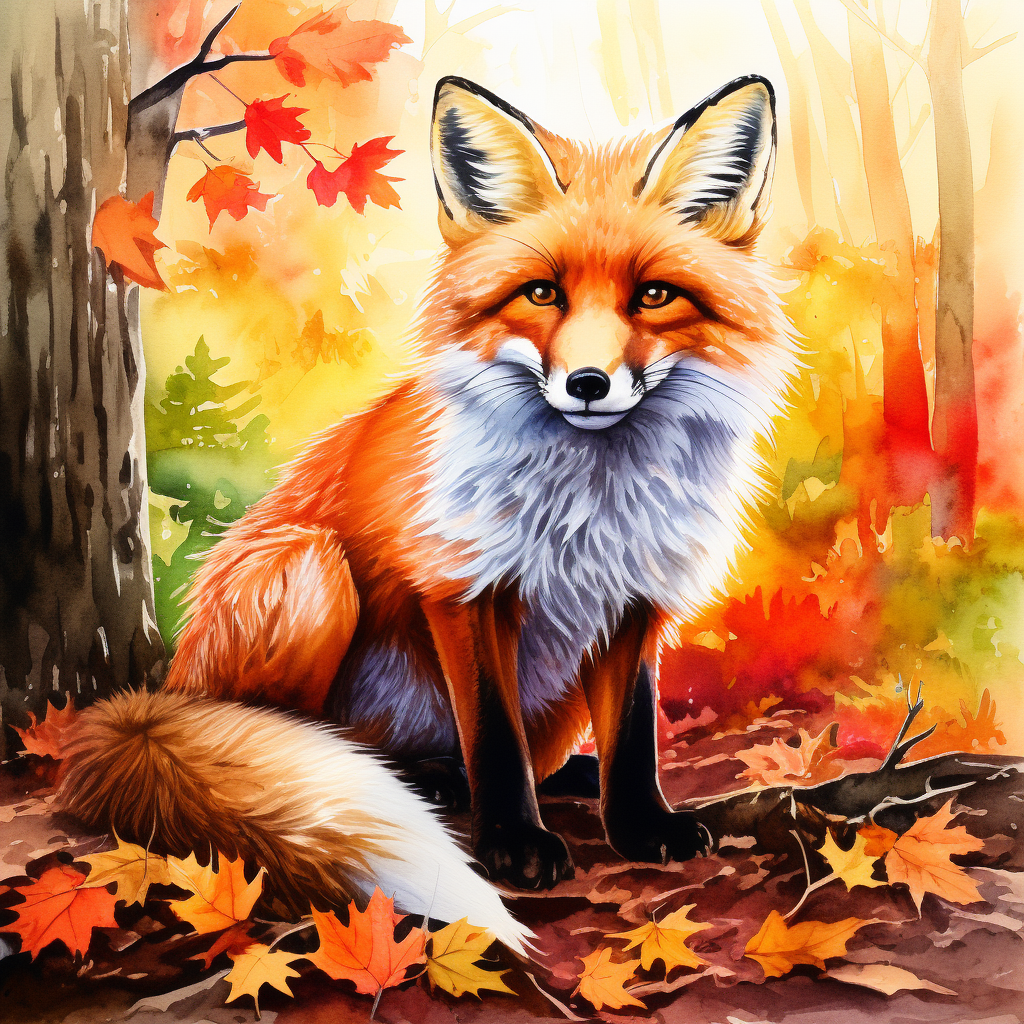

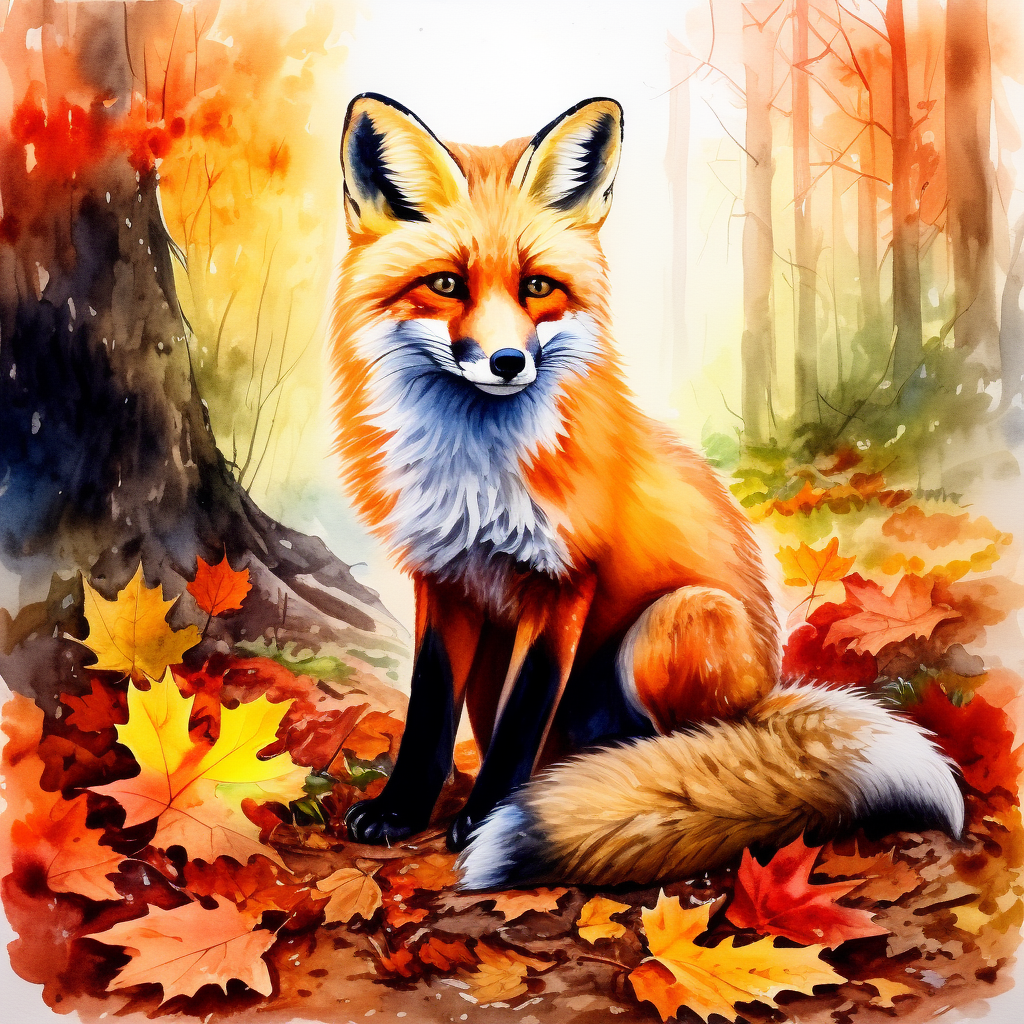

: 

In [ ]:
from diffusers import SanaPipeline

# SANA 모델 로드
model_id = "Efficient-Large-Model/Sana_1600M_1024px_diffusers"

# 1. SanaPipeline을 사용하여 모델을 로드합니다.
# from_pretrained: HuggingFace Hub에서 사전학습된 모델을 다운로드하고 로드합니다.
# torch_dtype=torch.float16: 16비트 부동소수점으로 로드하여 메모리를 절약합니다.
pipe = SanaPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)
# GPU로 모델을 이동합니다. enable_model_cpu_offload()은 컴포넌트를 하나씩만 GPU에
# 올려 메모리를 절약합니다. pipe.to("cuda")와 동시에 사용하면 안 됩니다.
pipe.to(device)
# pipe.enable_model_cpu_offload()

# 2. 파이프라인을 호출하여 이미지를 2장 생성합니다.
# 동일 프롬프트에서 다양한 이미지를 얻기 위해 이미지마다 서로 다른 시드를 사용합니다.
# 참고: float16에서는 특정 프롬프트+시드 조합에서 수치 오버플로우가 발생할 수 있습니다.
#       검은 이미지가 생성되면 시드 값을 변경해보세요.
images = []
seeds = [42, 777]

# 이미지 생성을 위한 프롬프트 설정
positive_prompt = "A watercolor painting of a red fox sitting on a forest floor, vibrant autumn colors"

for i, seed in enumerate(seeds):
    # torch.Generator로 시드를 지정하여 재현 가능하면서도 다양한 이미지를 생성합니다.
    generator = torch.Generator(device=device).manual_seed(seed)

    result = pipe(
        prompt=positive_prompt,
        guidance_scale=4.5,          # 텍스트 조건 준수 정도
        num_inference_steps=20,      # 디노이징 단계 수
        height=1024,                 # 생성 이미지 높이
        width=1024,                  # 생성 이미지 너비
        generator=generator,         # 시드별 generator
    )
    img = result.images[0]
    images.append(img)

# 생성된 이미지 저장 및 출력
for i, img in enumerate(images):
    img.save(f"generated_image_{i}.png")
    display(img)

## Step 2: CLIP 모델을 사용한 생성 이미지 평가

### Concept Check

#### CLIP(Contrastive Language-Image Pretraining)이란?

CLIP은 OpenAI가 개발한 멀티모달 모델로, **이미지와 텍스트를 같은 임베딩 공간에 투영**하여 유사도를 계산합니다. 4억 개의 이미지-텍스트 쌍으로 대조학습(Contrastive Learning)되어, 별도 학습 없이도 이미지가 어떤 텍스트 설명과 가장 어울리는지 판단할 수 있습니다.

**CLIP의 동작 원리:**
1. 이미지 인코더(ViT)가 이미지를 벡터로 변환
2. 텍스트 인코더(Transformer)가 텍스트를 벡터로 변환
3. 두 벡터 간 코사인 유사도를 계산하여 매칭 점수 산출

**평가 방식:**
- 정답 레이블: `"a watercolor painting of a fox"` (수채화 여우 그림)
- 오답 레이블: `"a watercolor painting of a dog"`, `"an oil painting of a fox"`, `"a photo of a fox"` 등
- CLIP은 이미지와 각 텍스트의 유사도를 비교하여 가장 높은 점수의 레이블을 예측합니다.

이제 생성된 이미지를 CLIP 모델로 평가해봅시다. 생성 이미지의 내용에 맞는 정답 레이블 한 개와, 모델이 혼동할 법한 오답 레이블 몇 개를 정합니다.

### TODO 2: CLIP 이미지-텍스트 유사도 계산

CLIP 모델과 프로세서를 로드하고, 생성된 이미지와 텍스트 레이블 간 유사도를 계산합니다.

**요구사항:**
1. `CLIPProcessor`와 `CLIPModel`을 `"openai/clip-vit-base-patch32"`에서 로드하세요.
2. `processor`를 사용하여 이미지와 텍스트 레이블을 전처리하세요.
   - `return_tensors="pt"`, `padding=True` 옵션을 사용하세요.
3. CLIP 모델로 `logits_per_image`를 계산하고, `softmax`로 확률을 구하세요.

가장 높은 유사도를 가진 레이블을 확인해봅시다.

In [ ]:
# 평가할 이미지 불러오기
image = Image.open("generated_image_0.png")

# 평가에 사용할 텍스트 레이블 정의
labels = [
    "a watercolor painting of a fox",   # 정답 (의도한 레이블)
    "a watercolor painting of a dog",   # 오답 후보 1 (동물만 다름)
    "an oil painting of a fox",         # 오답 후보 2 (화풍만 다름)
    "a photo of a fox"                  # 오답 후보 3 (스타일이 사진으로 다름)
]

# 1. `CLIPProcessor`와 `CLIPModel`을 `"openai/clip-vit-base-patch32"`에서 로드하세요.
from transformers import CLIPProcessor, CLIPModel

clip_model_id = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)

# 2. `processor`를 사용하여 이미지와 텍스트 레이블을 전처리하세요.
# return_tensors="pt": PyTorch 텐서로 반환
# padding=True: 문장 길이를 맞추기 위해 패딩 추가
inputs = processor(text=labels, images=image, return_tensors="pt", padding=True).to(device)

# 3. CLIP 모델로 `logits_per_image`를 계산하고, `softmax`로 확률을 구하세요.
with torch.no_grad():
    # logits_per_image: 이미지와 각 텍스트 레이블 간 유사도 점수
    outputs = clip_model(**inputs)
    logits_per_image = outputs.logits_per_image

    # softmax로 확률 분포로 변환 (합 = 1)
    probs = logits_per_image.softmax(dim=1)


# 결과 출력
print("CLIP similarity scores:", logits_per_image.cpu().numpy())
print("CLIP predicted probabilities:", probs.cpu().numpy())

best_idx = logits_per_image.argmax(dim=1).item()
print(f"\nCLIP 예측 결과: '{labels[best_idx]}' 라벨이 가장 타당하다고 예측되었습니다.")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

c:\Users\SSAFY\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SSAFY\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

## Step 3: ResNet-50 기반 모델과의 결과 비교

### Concept Check

#### ResNet-50과 CLIP의 차이

동일한 이미지를 전통적인 CNN 분류 모델인 **ResNet-50**과 멀티모달 모델인 **CLIP**으로 분석하면, 두 모델의 근본적인 차이를 확인할 수 있습니다.

| 구분 | ResNet-50 | CLIP |
|------|-----------|------|
| **학습 방식** | ImageNet 1000개 클래스 지도학습 | 4억 이미지-텍스트 쌍 대조학습 |
| **출력** | 고정된 1000개 클래스 확률 | 임의 텍스트와의 유사도 점수 |
| **화풍 인식** | 불가 (클래스에 없음) | 가능 (텍스트로 표현 가능) |
| **유연성** | 사전 정의된 범주만 분류 | 새로운 개념도 텍스트로 평가 가능 |

예를 들어 수채화 여우 그림에 대해:
- **CLIP**: "수채화 여우 그림" vs "유화 여우 그림" vs "사진 여우" 등을 비교하여 스타일까지 파악
- **ResNet-50**: 여우류 클래스("red fox", "kit fox" 등)로만 분류하며, 화풍 구분 불가

### TODO 3: ResNet-50으로 이미지 분류

ImageNet으로 사전학습된 ResNet-50 모델을 로드하고, 생성된 이미지를 분류하여 CLIP 결과와 비교합니다.

**요구사항:**
1. `models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)`로 사전학습된 모델을 로드하고 평가 모드(`.eval()`)로 설정하세요.
2. 이미지를 ResNet-50 입력에 맞게 전처리하세요
   1. 224x224 리사이즈
   2. ToTensor
   3. ImageNet 정규화. (정규화 평균: `[0.485, 0.456, 0.406]`, 표준편차: `[0.229, 0.224, 0.225]`)
3. ResNet-50으로 예측하고 `probs`에 할당해주세요.

In [ ]:
# 1. `models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)`로
# 사전학습된 모델을 로드하고 평가 모드(`.eval()`)로 설정하세요.
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2).to(device)
resnet50.eval()  # 평가 모드 설정 (Dropout, BatchNorm 비활성화)

# ImageNet 클래스 이름 매핑 가져오기
imagenet_classes = models.ResNet50_Weights.IMAGENET1K_V2.meta["categories"]
print("ImageNet 클래스 목록 (일부):", imagenet_classes[:10])

# 2. 이미지를 ResNet-50 입력에 맞게 전처리하세요
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),   # ResNet 입력 크기로 조정
    transforms.ToTensor(),            # [0, 1] 범위의 텐서로 변환
    transforms.Normalize(             # ImageNet 통계치로 정규화
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# .unsqueeze(0): 배치 차원 추가 [C, H, W] -> [1, C, H, W]
img_tensor = preprocess(image).unsqueeze(0).to(device)

# 3. ResNet-50으로 예측하고 `probs`에 할당해주세요. Top-5 결과를 출력하세요.
with torch.no_grad():
    output = resnet50(img_tensor)
probs = torch.nn.functional.softmax(output, dim=1)[0]

# Top-5 예측 결과
top5_prob, top5_idx = probs.topk(5)
top5_prob = top5_prob.cpu().numpy()
top5_idx = top5_idx.cpu().numpy()

class_idx = top5_idx[0]
class_name = imagenet_classes[class_idx]
print(f"\nResNet-50 예측 1순위: 클래스 #{class_idx} ({class_name}), 확률 {top5_prob[0]:.4f}")
print("Top-5 예측:", [(imagenet_classes[idx], f"{prob:.4f}") for idx, prob in zip(top5_idx, top5_prob)])

#### CLIP과 ResNet-50 비교 요약

위 결과를 비교해보면:
- **CLIP**은 우리가 정의한 문장 단위의 라벨을 통해 이미지가 *"여우 그림"*임을 알아채고, 스타일(수채화/유화/사진)까지 구분할 수 있었습니다.
- **ResNet-50**은 해당 그림을 여우로 인식했지만, 결과는 여우 종류(red fox, kit fox 등)로만 출력될 뿐 화풍 정보는 담지 못합니다.

이처럼 CLIP은 유연한 텍스트 설명으로 이미지의 다양한 측면을 평가할 수 있고, ResNet과 같은 CNN은 학습된 범주 내에서만 분류한다는 근본적인 차이가 있습니다.

## Step 4: 생성 데이터로 ResNet-18 전이학습 (리니어 프로빙)

### Concept Check

#### 전이학습(Transfer Learning)과 리니어 프로빙

**전이학습**은 대규모 데이터로 사전학습된 모델의 특징 추출 능력을 새로운 태스크에 활용하는 기법입니다. **리니어 프로빙(Linear Probing)**은 전이학습의 가장 단순한 형태로, 기존 모델의 가중치를 모두 고정(freeze)하고 **마지막 출력층(fc layer)만 새로 학습**합니다.

**리니어 프로빙 절차:**
1. 사전학습된 모델(ResNet-18) 로드
2. 기존 가중치 전체를 `requires_grad = False`로 고정
3. 마지막 fc층을 우리 데이터의 클래스 수에 맞게 교체
4. 새로운 fc층만 학습 (적은 데이터로도 빠르게 수렴)

#### 합성 데이터를 활용한 학습

SANA 등 생성 모델로 만든 **합성 데이터(Synthetic Data)**는 실제 데이터가 부족할 때 학습 데이터를 보강하는 데 활용할 수 있습니다. 이 실습에서는 SANA로 fox/dog 이미지를 여러 장 생성하여 2클래스 분류 데이터셋을 구성합니다.

**전이학습에 사용할 학습/테스트 데이터를 SANA로 생성합니다.** 각 클래스(fox, dog)별로 이미지를 생성하여 폴더 구조로 저장합니다. 이미지마다 서로 다른 시드를 사용하여 다양한 결과물을 확보합니다.

In [ ]:
# 합성 데이터셋 생성을 위한 클래스와 프롬프트 정의
classes = {
    "fox": "a watercolor painting of a red fox sitting on a forest floor, detailed, vibrant",
    "dog": "a watercolor painting of a golden retriever sitting on grass, detailed, vibrant"
}

# 이미지마다 다른 시드를 사용하여 다양한 결과물을 생성합니다.
train_seeds = [42, 777]
test_seeds = [2024, 3000]

# 학습 데이터 생성
os.makedirs("data/train/fox", exist_ok=True)
os.makedirs("data/train/dog", exist_ok=True)

for cls, prompt in classes.items():
    for i, seed in enumerate(train_seeds):
        generator = torch.Generator(device=device).manual_seed(seed)
        result = pipe(
            prompt=prompt,
            guidance_scale=4.5,
            num_inference_steps=20,
            height=1024,
            width=1024,
            generator=generator,
        )
        img = result.images[0]
        img.save(f"data/train/{cls}/{cls}_{i}.png")
        display(img)

# ImageFolder를 통해 데이터셋 로드
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
train_dataset = ImageFolder("data/train", transform=train_transforms)
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
print(f"생성된 학습 이미지 수: {len(train_dataset)} (클래스: {train_dataset.classes})")

# 테스트 데이터 생성
os.makedirs("data/test/fox", exist_ok=True)
os.makedirs("data/test/dog", exist_ok=True)

for cls, prompt in classes.items():
    for i, seed in enumerate(test_seeds):
        generator = torch.Generator(device=device).manual_seed(seed)
        result = pipe(
            prompt=prompt,
            guidance_scale=4.5,
            num_inference_steps=20,
            height=1024,
            width=1024,
            generator=generator,
        )
        img = result.images[0]
        img.save(f"data/test/{cls}/{cls}_{i}.png")
        display(img)

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
test_dataset = ImageFolder("data/test", transform=test_transforms)
test_loader = DataLoader(test_dataset, batch_size=5, shuffle=True)
print(f"생성된 테스트 이미지 수: {len(test_dataset)} (클래스: {test_dataset.classes})")

### TODO 4: ResNet-18 전이학습 구현

사전학습된 ResNet-18 모델을 로드하고, 지난 실습 3-1에서 수행한 것처럼 기존 가중치를 고정한 뒤 출력층을 교체하여 합성 데이터로 학습합니다.

**요구사항:**
1. `models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)`으로 모델을 로드하세요.
2. 기존 가중치 고정 (Freeze): 사전학습된 특징 추출 능력은 유지하고, 출력층만 새로 학습합니다.
3. 출력층(fc layer) 교체: `model.fc`의 입력 뉴런 수를 확인하고, 우리 클래스 수에 맞게 새 레이어를 생성합니다.
4. 손실 함수(`nn.CrossEntropyLoss`)와 옵티마이저(`optim.SGD`, lr=0.001, momentum=0.9)를 정의하세요. 옵티마이저는 `model.fc.parameters()`만 학습하도록 설정하세요.
5. 3 에포크 동안 학습 루프를 작성하세요.


In [ ]:
# 1. 사전학습된 ResNet-18 모델 로드
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 2. 기존 가중치 고정 (Freeze): 사전학습된 특징 추출 능력은 유지하고, 출력층만 새로 학습합니다.
for param in model.parameters():
    param.requires_grad = False

# 3. 출력층(fc layer) 교체:
# model.fc의 입력 뉴런 수를 확인하고, 우리 클래스 수에 맞게 새 레이어를 생성합니다.
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(train_dataset.classes))

model = model.to(device)

# 4. 손실 함수와 옵티마이저 정의
# 옵티마이저는 `model.fc.parameters()`만 학습하도록 설정하세요.
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.fc.parameters(), lr=0.001, momentum=0.9)

# 5. 학습 루프
model.train()
num_epochs = 3

for epoch in range(num_epochs):
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # 기울기 초기화
        optimizer.zero_grad()

        # 순전파: 모델 예측
        outputs = model(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 역전파: 기울기 계산
        loss.backward()

        # 파라미터 업데이트
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

학습이 완료되었습니다. 테스트 데이터로 모델을 평가해봅시다.

In [ ]:
# 이미지 역정규화 함수
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def denormalize(img_tensor, mean=mean, std=std):
    """정규화된 이미지 텐서를 [0, 1] 범위로 복원합니다."""
    mean_t = torch.tensor(mean, device=img_tensor.device).view(-1, 1, 1)
    std_t = torch.tensor(std, device=img_tensor.device).view(-1, 1, 1)
    img = img_tensor * std_t + mean_t
    return img.clamp(0, 1)

# 모델 평가
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = model(inputs)
        predicted = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # 예측 결과 시각화
        for img, pred in zip(inputs, predicted):
            _img = denormalize(img).cpu()
            print(f"예측 결과: {train_dataset.classes[pred]}")
            display(transforms.ToPILImage()(_img))

print(f"\n테스트 데이터셋에서 모델 정확도: {100 * correct / total:.2f}%")

## 학생용 자가 체크리스트

- [ ] **이미지 생성**: SANA 파이프라인을 로드하고 프롬프트 기반으로 이미지를 생성할 수 있다.
- [ ] **CLIP 평가**: CLIP 모델로 이미지와 텍스트 간 유사도를 측정하고 결과를 해석할 수 있다.
- [ ] **모델 비교**: CLIP과 ResNet-50의 분류 결과 차이를 설명할 수 있다.
- [ ] **전이학습 구현**: ResNet-18의 가중치를 고정하고 fc층을 교체하여 리니어 프로빙을 구현할 수 있다.
- [ ] **합성 데이터 활용**: 생성 모델로 합성 데이터셋을 구성하고 모델 학습에 활용하는 파이프라인을 이해한다.

### **Content License Agreement**

<font color='red'><b>**WARNING**</b></font> : 본 자료는 삼성청년SW·AI아카데미의 컨텐츠 자산으로, 보안서약서에 의거하여 어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다.